# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
data = pd.read_csv('AviationData_Cleaned.csv')
data.head()

<ipython-input-2-637dd6699579>:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('AviationData_Cleaned.csv')


,event_id,investigation_type,accident_number,event_date,location,country,airport_code,airport_name,injury_severity,aircraft_damage,...,number_of_engines,engine_type,purpose_of_flight,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,broad_phase_of_flight,is_destroyed
0,20001214X42095,Accident,SEA83LA036,1983-01-01,"NEWPORT, OR",United States,ONP,NEWPORT MUNICIPAL,Non-Fatal,Substantial,...,1.0,reciprocating,personal,0.0,0.0,1.0,3.0,vmc,approach,False
1,20001214X42067,Accident,MKC83LA056,1983-01-01,"WOODBINE, IA",United States,3YR,MUNICIPAL,Non-Fatal,Substantial,...,1.0,reciprocating,personal,0.0,0.0,0.0,2.0,vmc,landing,False
2,20001214X42063,Accident,MKC83LA050,1983-01-01,"MARYVILLE, MO",United States,78Y,RANKIN,Non-Fatal,Substantial,...,1.0,reciprocating,personal,0.0,0.0,0.0,1.0,vmc,takeoff,False
3,20001214X42018,Accident,LAX83FUG11,1983-01-01,"UPLAND, CA",United States,CCB,CABLE,Non-Fatal,Substantial,...,1.0,reciprocating,personal,0.0,0.0,2.0,0.0,vmc,approach,False
4,20001214X41951,Accident,CHI83LA074,1983-01-01,"SPRINGBROOK, WI",United States,NaN,SPRINGBROOK,Non-Fatal,Substantial,...,1.0,reciprocating,instructional,0.0,0.0,0.0,2.0,vmc,landing,False


In [4]:
data.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'airport_code', 'airport_name',
       'injury_severity', 'aircraft_damage', 'aircraft_category', 'make',
       'model', 'amateur_built', 'number_of_engines', 'engine_type',
       'purpose_of_flight', 'total_fatal_injuries', 'total_serious_injuries',
       'total_minor_injuries', 'total_uninjured', 'weather_condition',
       'broad_phase_of_flight', 'is_destroyed'],
      dtype='object')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
# Creating a total passengers column by adding the number of total fatal injuries, total serious injuries, total minor injuries, and total uninjured
data['total_passengers'] = (
    data['total_fatal_injuries'] +
    data['total_serious_injuries'] +
    data['total_minor_injuries'] +
    data['total_uninjured']
)
# Creating a aircraft size thrresholhold based on number of passengers
data['aircraft_size'] = np.where(
    data['total_passengers'] < 20,
    'Small Aircraft',
    'Large Aircraft'
)

In [6]:
# New colunm 'aircaft' where it gives the make and model
data['aircraft'] = data['make'] + " " + data['model']

In [7]:
# Separating small vs large aircrafts
small_aircraft = data[data['aircraft_size'] == 'Small Aircraft']
large_aircraft = data[data['aircraft_size'] == 'Large Aircraft']

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [18]:
# Convert injury columns to numeric
# Standardize column names first
data.columns = data.columns.str.lower().str.replace('.', '_')

# Convert injury columns to numeric
cols = [
    'total_fatal_injuries',
    'total_serious_injuries',
    'total_minor_injuries',
    'total_uninjured'
]

for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)

# Total passengers
data['total_passengers'] = (
    data['total_fatal_injuries'] +
    data['total_serious_injuries'] +
    data['total_minor_injuries'] +
    data['total_uninjured']
)

# Fatal + serious injuries
data['fatal_serious_injuries'] = (
    data['total_fatal_injuries'] +
    data['total_serious_injuries']
)

# Injury rate
data['injury_rate'] = (
    data['fatal_serious_injuries'] / data['total_passengers']
)

# Clean invalid values
data['injury_rate'] = (
    data['injury_rate']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Verify creation
data[['injury_rate']].head()


<ipython-input-18-d33aed9ed6e9>:3: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  data.columns = data.columns.str.lower().str.replace('.', '_')


,injury_rate
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [20]:
data.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'airport_code', 'airport_name',
       'injury_severity', 'aircraft_damage', 'aircraft_category', 'make',
       'model', 'amateur_built', 'number_of_engines', 'engine_type',
       'purpose_of_flight', 'total_fatal_injuries', 'total_serious_injuries',
       'total_minor_injuries', 'total_uninjured', 'weather_condition',
       'broad_phase_of_flight', 'is_destroyed', 'total_passengers',
       'aircraft_size', 'aircraft', 'fatal_serious_injuries', 'injury_rate'],
      dtype='object')

In [23]:
# Recreate aircraft size groups AFTER creating injury_rate

small_aircraft = data[data['aircraft_size'] == 'Small Aircraft']

large_aircraft = data[data['aircraft_size'] == 'Large Aircraft']

In [24]:
# Injury rate forsmall aircrafts
small_make_stats = small_aircraft.groupby('make').agg(
    mean_injury_rate=('injury_rate', 'mean'),
    sample_size=('make', 'count')
).reset_index()

# Keep statistically reliable makes
small_make_stats = small_make_stats[
    small_make_stats['sample_size'] >= 30
]

# Lowest injury rates first
small_make_stats = small_make_stats.sort_values(
    'mean_injury_rate'
)

# Top 15 safest makes
top15_small = small_make_stats.head(15)

In [25]:
# Injury rate for large aircrafts
large_make_stats = large_aircraft.groupby('make').agg(
    mean_injury_rate=('injury_rate', 'mean'),
    sample_size=('make', 'count')
).reset_index()

# Keep statistically reliable makes
large_make_stats = large_make_stats[
    large_make_stats['sample_size'] >= 30
]

# Lowest injury rates first
large_make_stats = large_make_stats.sort_values(
    'mean_injury_rate'
)

# Top 15 safest makes
top15_large = large_make_stats.head(15)

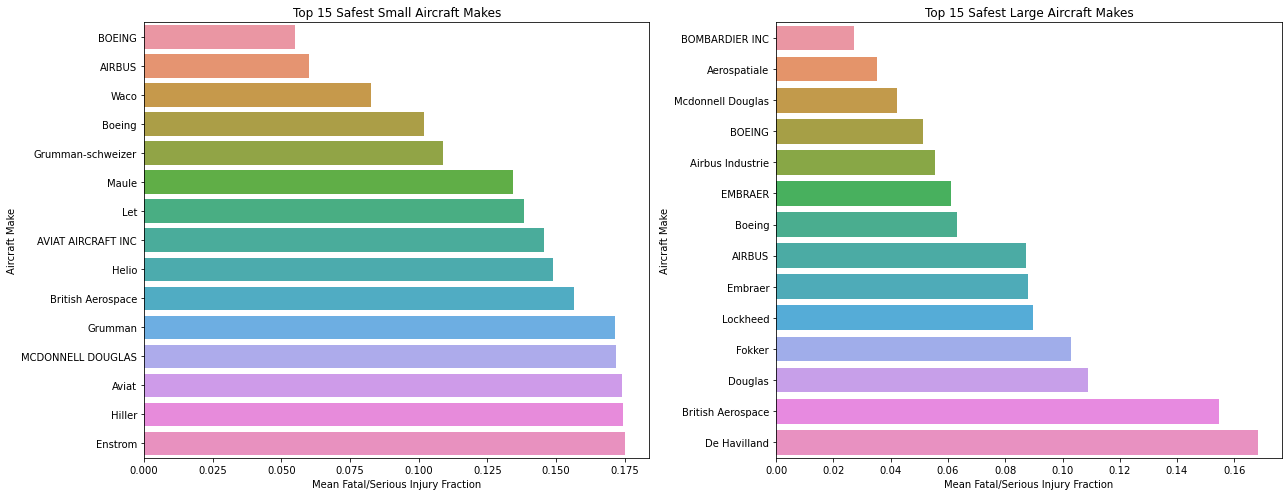

In [26]:
# Visualization of small vs large aircraft injury rates
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Small aircraft plot
sns.barplot(
    data=top15_small,
    x='mean_injury_rate',
    y='make',
    ax=axes[0]
)

axes[0].set_title("Top 15 Safest Small Aircraft Makes")
axes[0].set_xlabel("Mean Fatal/Serious Injury Fraction")
axes[0].set_ylabel("Aircraft Make")

# Large aircraft plot
sns.barplot(
    data=top15_large,
    x='mean_injury_rate',
    y='make',
    ax=axes[1]
)

axes[1].set_title("Top 15 Safest Large Aircraft Makes")
axes[1].set_xlabel("Mean Fatal/Serious Injury Fraction")
axes[1].set_ylabel("Aircraft Make")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [32]:
# Mean injury rates by manufacturer
small_make_stats = small_aircraft.groupby('make').agg(
    mean_injury_rate=('injury_rate', 'mean'),
    sample_size=('make', 'count')
).reset_index()

# Keep statistically reliable makes
small_make_stats = small_make_stats[
    small_make_stats['sample_size'] >= 30
]

# Top 10 safest makes
top10_small_makes = (
    small_make_stats
    .sort_values('mean_injury_rate')
    .head(10)
)

top10_small_makes

,make,mean_injury_rate,sample_size
18,BOEING,0.054845,671
4,AIRBUS,0.060043,147
110,Waco,0.082609,115
24,Boeing,0.102066,611
57,Grumman-schweizer,0.108815,121
72,Maule,0.134424,428
66,Let,0.138393,112
5,AVIAT AIRCRAFT INC,0.145833,72
60,Helio,0.149047,89
26,British Aerospace,0.156750,52


In [33]:
top10_make_names = top10_small_makes['make']

small_top10_df = small_aircraft[
    small_aircraft['make'].isin(top10_make_names)
]

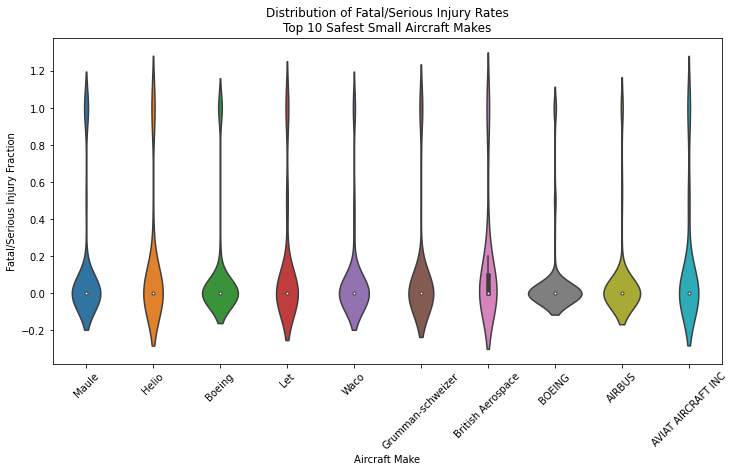

In [34]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=small_top10_df,
    x='make',
    y='injury_rate'
)

plt.title("Distribution of Fatal/Serious Injury Rates\nTop 10 Safest Small Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal/Serious Injury Fraction")

plt.xticks(rotation=45)

plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [38]:
large_make_stats = large_aircraft.groupby('make').agg(
    mean_injury_rate=('injury_rate', 'mean'),
    sample_size=('make', 'count')
).reset_index()

# Keep statistically reliable makes
large_make_stats = large_make_stats[
    large_make_stats['sample_size'] >= 30
]

# Select 10 safest large aircraft makes
top10_large_makes = (
    large_make_stats
    .sort_values('mean_injury_rate')
    .head(10)
)

top10_large_makes

,make,mean_injury_rate,sample_size
6,BOMBARDIER INC,0.027116,46
2,Aerospatiale,0.035119,34
28,Mcdonnell Douglas,0.042028,303
5,BOEING,0.051198,474
3,Airbus Industrie,0.055281,119
18,EMBRAER,0.061163,65
9,Boeing,0.063137,933
0,AIRBUS,0.087138,104
19,Embraer,0.087844,46
26,Lockheed,0.089796,39


In [39]:
top10_large_names = top10_large_makes['make']

large_top10_df = large_aircraft[
    large_aircraft['make'].isin(top10_large_names)
]

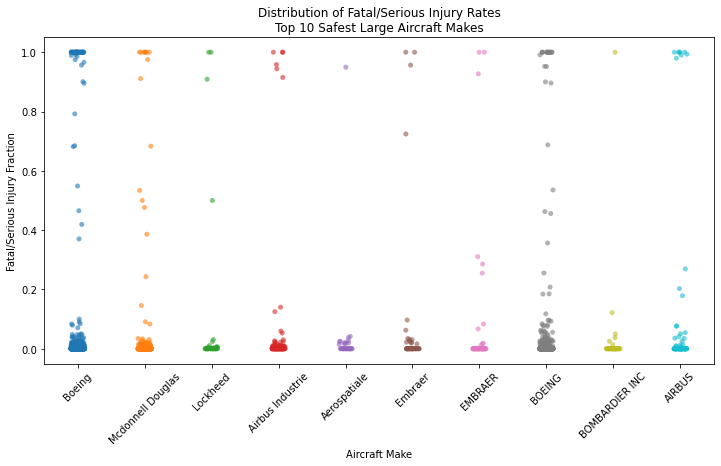

In [40]:
plt.figure(figsize=(12,6))

sns.stripplot(
    data=large_top10_df,
    x='make',
    y='injury_rate',
    jitter=True,
    alpha=0.6
)

plt.title("Distribution of Fatal/Serious Injury Rates\nTop 10 Safest Large Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal/Serious Injury Fraction")

plt.xticks(rotation=45)

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [ ]:
# Destruction rate by make for small aircraft
small_destroyed = (
    small_aircraft.groupby('make')
    .agg(
        destroyed_fraction=('aircraft_damage', lambda x: (x == 'Destroyed').mean()),
        mean_injury_rate=('injury_rate', 'mean'),
        sample_size=('make', 'count')
    )
    .query('sample_size >= 5')
    .sort_values('destroyed_fraction')
    .head(15)
)

# Destruction rate by make for large aircraft
large_destroyed = (
    large_aircraft.groupby('make')
    .agg(
        destroyed_fraction=('aircraft_damage', lambda x: (x == 'Destroyed').mean()),
        mean_injury_rate=('injury_rate', 'mean'),
        sample_size=('make', 'count')
    )
    .query('sample_size >= 5')
    .sort_values('destroyed_fraction')
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=small_destroyed.reset_index(),
    x='destroyed_fraction',
    y='make',
    ax=axes[0]
)
axes[0].set_title('Small Aircraft Makes with Lowest Destruction Rates')
axes[0].set_xlabel('Destroyed Fraction')

sns.barplot(
    data=large_destroyed.reset_index(),
    x='destroyed_fraction',
    y='make',
    ax=axes[1]
)
axes[1].set_title('Large Aircraft Makes with Lowest Destruction Rates')
axes[1].set_xlabel('Destroyed Fraction')

plt.tight_layout()
plt.show()

small_destroyed.head()
large_destroyed.head()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Findings and Recommendations

#### Small Aircraft
- Small aircraft manufacturers with consistently low injury rates and low destruction fractions appear to provide safer outcomes during accidents.
- The violin plots suggest that some manufacturers have highly variable injury outcomes, while others show more stable and lower-risk distributions.
- Makes with both low mean injury rates and narrow distributions should be prioritized for safety-focused recommendations.

#### Large Aircraft
- Large commercial aircraft generally show lower injury variability compared to small aircraft.
- Certain large-aircraft manufacturers consistently demonstrate lower serious/fatal injury rates and lower aircraft destruction probabilities.
- Manufacturers with large sample sizes and consistently low injury fractions provide the most reliable safety performance indicators.

#### General Observations
- Aircraft size influences passenger safety outcomes.
- Injury rates tend to increase when aircraft are fully destroyed.
- Manufacturers with very small sample sizes should be interpreted cautiously because a few accidents can heavily influence averages.

#### Recommendation
For insurance and operational purposes:
1. Prioritize aircraft manufacturers with:
   - low average injury fractions,
   - low destruction fractions,
   - and large historical sample sizes.
2. Large commercial aircraft generally provide safer passenger outcomes than small aircraft.
3. Additional operational factors such as weather, engine type, and flight phase should also be considered in risk evaluation.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [ ]:
# Large aircraft model analysis
large_model_stats = (
    large_aircraft.groupby('aircraft')
    .agg(
        mean_injury_rate=('injury_rate', 'mean'),
        sample_size=('aircraft', 'count')
    )
    .query('sample_size >= 5')
    .sort_values('mean_injury_rate')
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=large_model_stats.reset_index(),
    x='mean_injury_rate',
    y='aircraft'
)

plt.title('Large Aircraft Models with Lowest Mean Injury Rates')
plt.xlabel('Mean Serious/Fatal Injury Fraction')
plt.ylabel('Aircraft Model')

plt.tight_layout()
plt.show()

# Distribution plot
top_large_models = large_model_stats.index

large_model_df = large_aircraft[
    large_aircraft['aircraft'].isin(top_large_models)
]

plt.figure(figsize=(14,6))

sns.stripplot(
    data=large_model_df,
    x='aircraft',
    y='injury_rate',
    jitter=True
)

plt.xticks(rotation=45)
plt.title('Distribution of Injury Rates for Large Aircraft Models')

plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [ ]:
# Small aircraft model analysis
small_model_stats = (
    small_aircraft.groupby('aircraft')
    .agg(
        mean_injury_rate=('injury_rate', 'mean'),
        sample_size=('aircraft', 'count')
    )
    .query('sample_size >= 5')
    .sort_values('mean_injury_rate')
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=small_model_stats.reset_index(),
    x='mean_injury_rate',
    y='aircraft'
)

plt.title('Small Aircraft Models with Lowest Mean Injury Rates')
plt.xlabel('Mean Serious/Fatal Injury Fraction')
plt.ylabel('Aircraft Model')

plt.tight_layout()
plt.show()

# Distribution plot
top_small_models = small_model_stats.index

small_model_df = small_aircraft[
    small_aircraft['aircraft'].isin(top_small_models)
]

plt.figure(figsize=(14,6))

sns.violinplot(
    data=small_model_df,
    x='aircraft',
    y='injury_rate'
)

plt.xticks(rotation=45)
plt.title('Distribution of Injury Rates for Small Aircraft Models')

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion of Aircraft Models

#### Large Aircraft Models
- Large aircraft models generally display lower injury fractions and less variability in outcomes.
- Models with consistently low injury rates are likely designed with stronger structural integrity and more advanced passenger protection systems.
- The stripplot demonstrates that while some incidents still produce higher injury rates, most outcomes cluster near lower values.

#### Small Aircraft Models
- Small aircraft models show wider variability in injury outcomes.
- Some models demonstrate relatively safe performance, but others show extreme outliers with high passenger injury fractions.
- The violin plots highlight the uneven distribution of safety outcomes among smaller aircraft types.

#### Overall Interpretation
- Commercial large aircraft appear safer on average compared to smaller aircraft.
- Aircraft model selection significantly impacts risk exposure.
- Combining injury rates with destruction rates gives a more balanced measure of aircraft safety.


### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [29]:
# Creating a new column total injuries where we add total fatal injuries, total minor injuries and tottal serious injuries
data['total_injuries'] = (
    data['total_fatal_injuries'] +
    data['total_minor_injuries'] +
    data['total_serious_injuries']
)

<AxesSubplot:xlabel='weather_condition', ylabel='total_injuries'>

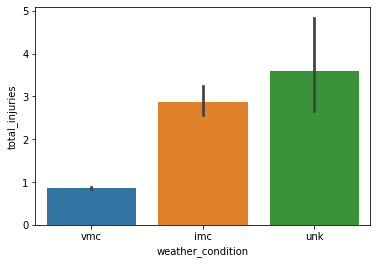

In [30]:
# Weather conditions vs total injuries
sns.barplot(
    data=data,
    x='weather_condition',
    y='total_injuries'
)

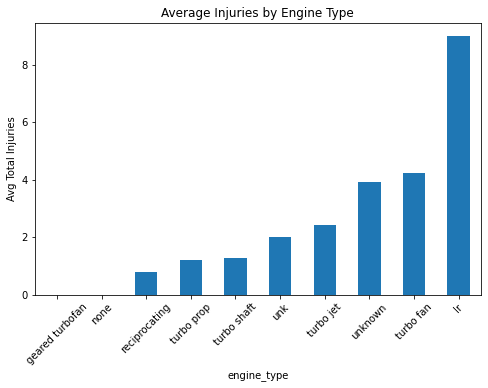

In [35]:
# Engine type vs total injuries
engine_plot = data.groupby('engine_type')['total_injuries'].mean().sort_values()
plt.figure(figsize=(8,5))
engine_plot.plot(kind='bar')
plt.title("Average Injuries by Engine Type")
plt.ylabel("Avg Total Injuries")
plt.xticks(rotation=45)
plt.show()

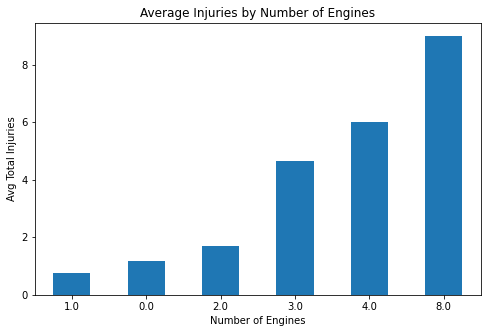

In [36]:
# Number of engines vs total injuries
engines_plot = data.groupby('number_of_engines')['total_injuries'].mean().sort_values()
plt.figure(figsize=(8,5))
engines_plot.plot(kind='bar')
plt.title("Average Injuries by Number of Engines")
plt.ylabel("Avg Total Injuries")
plt.xlabel("Number of Engines")
plt.xticks(rotation=0)
plt.show()

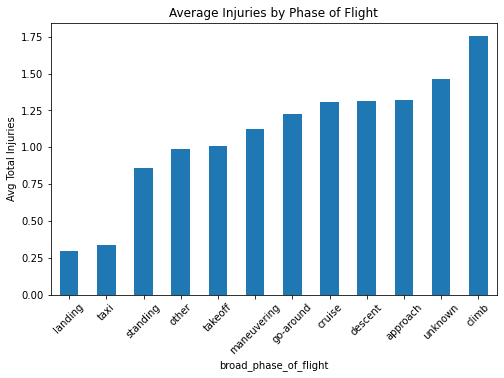

In [37]:
# Broad phase of flight vs total injuries
phase_plot = data.groupby('broad_phase_of_flight')['total_injuries'].mean().sort_values()
plt.figure(figsize=(8,5))
phase_plot.plot(kind='bar')
plt.title("Average Injuries by Phase of Flight")
plt.ylabel("Avg Total Injuries")
plt.xticks(rotation=45)
plt.show()